In [1]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'model' and 'networks' (current directory structure)
d = current_dir
for _ in range(5):
    if (d / "model").exists() and (d / "networks").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing

In this notebook we test that the main files work well.

## Setup

In [2]:
from utils.imports import *
from model.agents import BetaAgent, BayesAgent
from model.vectorized_model import VectorizedModel


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# n_agents = 100
# my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

In [4]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../networks/citation_data/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../networks/citation_data/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


## Try with Bayes Agent

In [ ]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True, sampling_update=True,
                 seed=seed, seeded=False, agent_type='bayes',
                 snapshot_interval=1000)
my_model.run_simulation(number_of_steps=100000, show_bar=True)
print('steps: ', my_model.n_steps)
print('conclusion: ', my_model.conclusion)
print('conclusion core', my_model.conclusion_core)
# df = pd.DataFrame(my_model.credences_history)
# df.head(3)


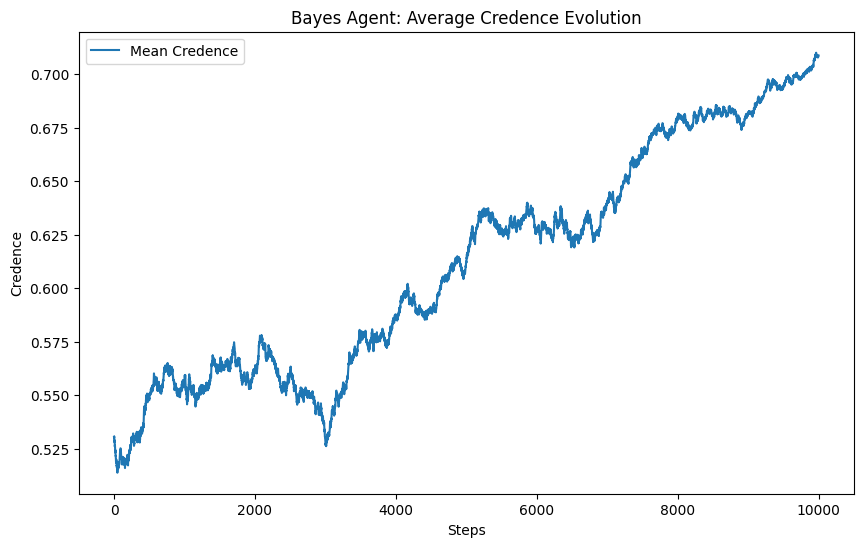

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()


## Try with Beta Agent

In [ ]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True, sampling_update=True,
                 seed=seed, seeded=False, agent_type='beta',
                 tolerance_stopping=False, tstep_stopping=True,
                 snapshot_interval=1000)

my_model.run_simulation(number_of_steps=100000, show_bar=True)
print('steps: ', my_model.n_steps)
print('conclusion: ', my_model.conclusion)
df = pd.DataFrame(my_model.credences_history)
df.head(3)


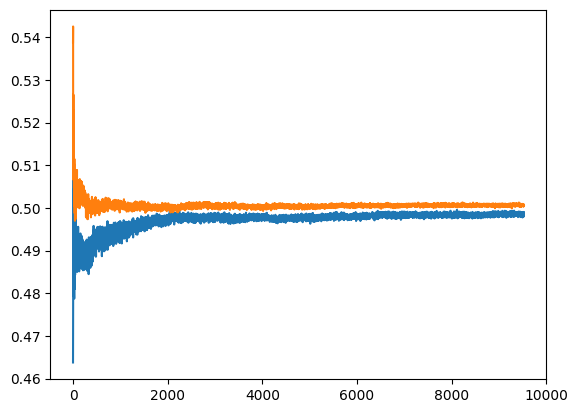

In [8]:
#Extract the first coordinate (x) for each pair and calculate column-wise mean
x_means = df.map(lambda pair: pair[0]).mean()
y_means = df.map(lambda pair: pair[1]).mean()
plt.plot(x_means)
plt.plot(y_means)

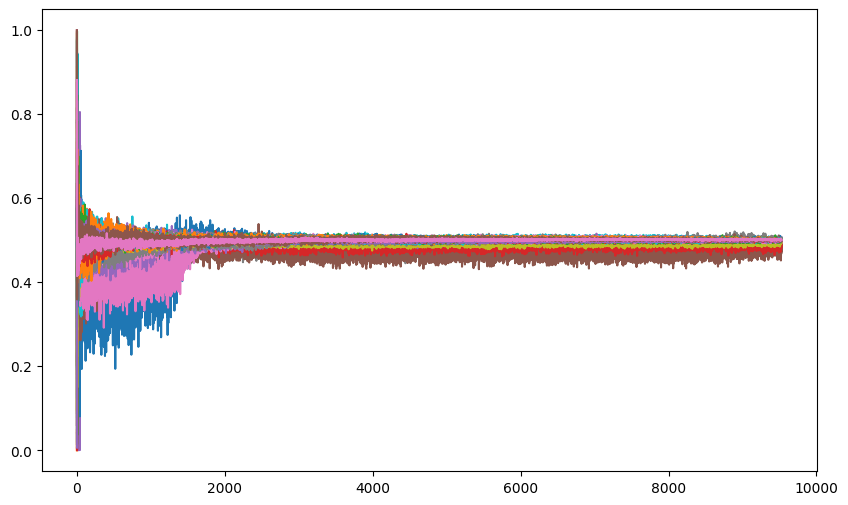

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row
plt.figure(figsize=(10, 6))
for row_idx in range(x_values.shape[0]):
    plt.plot(x_values.columns, x_values.iloc[row_idx, :], label=f'Row {row_idx+1}' if row_idx < 5 else None)

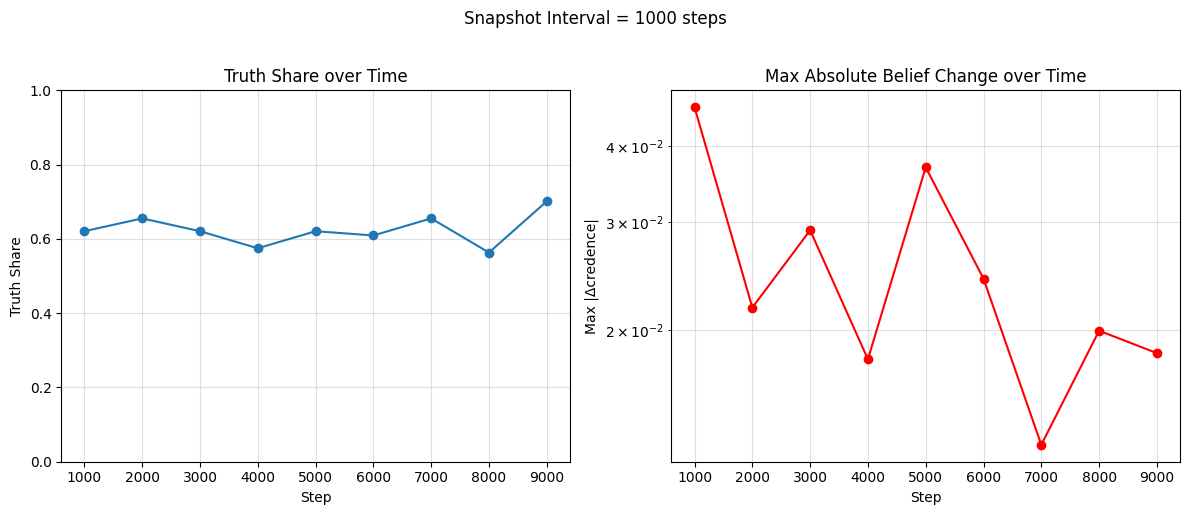

In [10]:
# ── Snapshot Trajectories ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

snapshots = my_model.snapshots

if snapshots and len(snapshots['step']) > 0:
    steps             = snapshots['step']
    truth_shares      = snapshots['truth_share']
    max_belief_changes = snapshots['max_belief_change']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(steps, truth_shares, marker='o', linestyle='-')
    axes[0].set_title('Truth Share over Time')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Truth Share')
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.4)

    # Filter out None values from bayes agents
    valid_changes = [(s, c) for s, c in zip(steps, max_belief_changes) if c is not None]
    if valid_changes:
        s_vals, c_vals = zip(*valid_changes)
        axes[1].plot(s_vals, c_vals, marker='o', linestyle='-', color='red')
        axes[1].set_title('Max Absolute Belief Change over Time')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Max |Δcredence|')
        axes[1].set_yscale('log')
        axes[1].grid(True, alpha=0.4, which='both')
    else:
        axes[1].set_visible(False)

    plt.suptitle(f'Snapshot Interval = {my_model.snapshot_interval} steps', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No snapshots recorded. Run with snapshot_interval > 0.')
